<a href="https://colab.research.google.com/github/rzvn6660/Medi-fy/blob/main/Medi_fy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pytesseract
!pip install opencv-python-headless
!pip install Pillow
!apt-get install tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 30 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 1s (3,423 kB/s)
Selecting previously unselected package tesseract-ocr-eng.
(Reading database ... 126210 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-

In [ ]:
!pip install ipywidgets==7.7.1
!sudo apt install tesseract-ocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.6 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.6 MB/s eta 0:00:00


In [ ]:
!which tesseract

/usr/bin/tesseract


In [ ]:
import pytesseract
pytesseract.pytesseract.tesseract_cmd = '/usr/bin/tesseract'

In [ ]:
!pip install fuzzywuzzy
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 26.5 MB/s eta 0:00:00


In [ ]:
!python --version

Python 3.11.11


In [ ]:
import pytesseract
from google.colab import files
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import re
import requests
import sqlite3
from fuzzywuzzy import fuzz
from fuzzywuzzy import process

# FDA API Configuration
API_KEY = "3Fujd8nvtqe7lKR9Ew4P3hU8X4laWusbAnyNDCZO"

In [ ]:
import gradio as gr
import pytesseract
from PIL import Image
import cv2
import numpy as np
import re
import csv

# Initialize medicine database
drug_db = {}

# Load medicine dataset from CSV
with open('/content/medicine_dataset_100 (1).csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        normalized_name = row['Medicine Name'].strip().lower()
        drug_db[normalized_name] = {
            'usage': row['Usage'],
            'side_effects': row['Side Effects'].split(', '),
            'dosage': row['Dosage']
        }

def process_image(image):
    try:
        img_array = np.array(image)
        gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)
        thresh = cv2.adaptiveThreshold(enhanced, 255,
                                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, 21, 4)
        custom_config = r'--oem 3 --psm 6'
        extracted_text = pytesseract.image_to_string(Image.fromarray(thresh), config=custom_config)
        return extracted_text
    except Exception as e:
        return f"Error processing image: {str(e)}"

def extract_medicine_name(text):
    text = re.sub(r'[^a-zA-Z0-9]', ' ', text).upper()
    text = re.sub(r'([a-z])([A-Z0-9])', r'\1 \2', text)
    matches = re.findall(r'\b([A-Z][A-Z0-9]+(?:\s+[A-Z][A-Z0-9]+)*)\b', text)

    exclude_terms = {'TABLETS', 'CAPSULES', 'IP', 'MG', 'ML'}
    for match in matches:
        parts = [word for word in match.split()
                if word not in exclude_terms and len(word) > 3]
        if parts:
            return ' '.join(parts).title()
    return None

def analyze_input(image, text_input):
    medicine_name = None

    if image is not None:
        extracted_text = process_image(image)
        medicine_name = extract_medicine_name(extracted_text)
    elif text_input:
        medicine_name = extract_medicine_name(text_input)

    if not medicine_name:
        return {"error": "Please provide either an image or text input"}, gr.update(visible=False)

    normalized_name = medicine_name.strip().lower()
    if normalized_name in drug_db:
        result = drug_db[normalized_name]
        result["Medicine Name"] = medicine_name
        return result, gr.update(visible=True)

    return {"error": f"Medicine '{medicine_name}' not found"}, gr.update(visible=False)

def show_info(info_type, data):
    if "error" in data:
        return data["error"]

    info = data.get(info_type.lower(), "Information not available")
    if isinstance(info, list):
        return "\n".join([f"• {item}" for item in info])
    return info

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 💊 Medicine Information System")
    gr.Markdown("Upload a medicine label image or enter the medicine name")

    with gr.Tabs():
        with gr.TabItem("📷 Image Upload"):
            image_input = gr.Image(label="Upload Medicine Label", type="pil")
        with gr.TabItem("📝 Text Input"):
            text_input = gr.Textbox(label="Enter Medicine Name")

    analyze_btn = gr.Button("Analyze Medicine", variant="primary")
    result_info = gr.JSON(visible=False)  # Hidden storage

    with gr.Row(visible=False) as btn_row:
        usage_btn = gr.Button("Show Usage", variant="secondary")
        side_effects_btn = gr.Button("Show Side Effects", variant="secondary")
        dosage_btn = gr.Button("Show Dosage", variant="secondary")

    info_output = gr.Textbox(label="Information", interactive=False)

    # Event handlers
    analyze_btn.click(
        fn=analyze_input,
        inputs=[image_input, text_input],
        outputs=[result_info, btn_row]
    )

    usage_btn.click(
        fn=lambda x: show_info("usage", x),
        inputs=result_info,
        outputs=info_output
    )

    side_effects_btn.click(
        fn=lambda x: show_info("side_effects", x),
        inputs=result_info,
        outputs=info_output
    )

    dosage_btn.click(
        fn=lambda x: show_info("dosage", x),
        inputs=result_info,
        outputs=info_output
    )

if __name__ == "__main__":
    demo.launch()

#  💊 Medi-Fy"
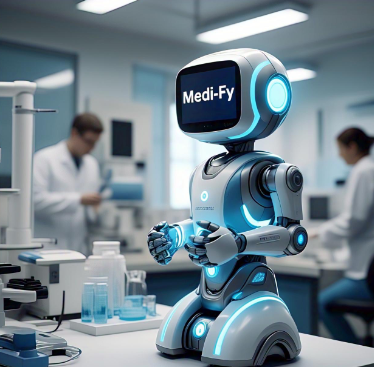


In [ ]:
import gradio as gr
import pytesseract
import requests
from PIL import Image
import cv2
import numpy as np
import re
import csv

# Initialize medicine database
drug_db = {}
API_KEY = "3Fujd8nvtqe7lKR9Ew4P3hU8X4laWusbAnyNDCZO"
name_mapping = {
    "paracetamol": "acetaminophen",
    "calpol": "acetaminophen",
    "dolo": "acetaminophen"
}

# Load medicine dataset from CSV
with open('/content/medicine_dataset_100 (1).csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        normalized_name = row['Medicine Name'].strip().lower()
        drug_db[normalized_name] = {
            'usage': row['Usage'],
            'side_effects': row['Side Effects'].split(', '),
            'dosage': row['Dosage']
        }

def fetch_medicine_description(scientific_name):
    try:
        url = f"https://api.fda.gov/drug/label.json?search=generic_name:{scientific_name}&limit=1&api_key={API_KEY}"
        response = requests.get(url)

        if response.status_code == 200:
            data = response.json()
            if data.get('results'):
                description = data['results'][0].get('description', ['No description available'])[0]
                return description

            if scientific_name.lower() == "acetaminophen":
                url = f"https://api.fda.gov/drug/label.json?search=brand_name:tylenol&limit=1&api_key={API_KEY}"
                response = requests.get(url)
                if response.status_code == 200 and data.get('results'):
                    description = data['results'][0].get('description', ['No description available'])[0]
                    return description
            return "No description found in OpenFDA database."
        return f"API Error: {response.status_code}"
    except Exception as e:
        return f"API Error: {str(e)}"

def process_image(image):
    try:
        img_array = np.array(image)
        gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)
        thresh = cv2.adaptiveThreshold(enhanced, 255,
                                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, 21, 4)
        custom_config = r'--oem 3 --psm 6'
        return pytesseract.image_to_string(Image.fromarray(thresh), config=custom_config)
    except Exception as e:
        return str(e)

def extract_medicine_name(text):
    text = re.sub(r'[^a-zA-Z0-9]', ' ', text).upper()
    text = re.sub(r'([a-z])([A-Z0-9])', r'\1 \2', text)
    matches = re.findall(r'\b([A-Z][A-Z0-9]+(?:\s+[A-Z][A-Z0-9]+)*)\b', text)
    exclude_terms = {'TABLETS', 'CAPSULES', 'IP', 'MG', 'ML'}
    for match in matches:
        parts = [word for word in match.split()
                if word not in exclude_terms and len(word) > 3]
        if parts: return ' '.join(parts).title()
    return None

def analyze_input(image, text_input):
    medicine_name = None

    if image is not None:
        medicine_name = extract_medicine_name(process_image(image))
    elif text_input:
        medicine_name = extract_medicine_name(text_input)

    if not medicine_name:
        return {"error": "Please provide either an image or text input"}, gr.update(visible=False)

    normalized_name = medicine_name.strip().lower()

    # Check local dataset first
    if normalized_name in drug_db:
        result = drug_db[normalized_name]
        result["Medicine Name"] = medicine_name
        result["source"] = "dataset"
        return result, gr.update(visible=True)

    # Check OpenFDA API
    api_name = name_mapping.get(normalized_name, normalized_name)
    description = fetch_medicine_description(api_name)

    if not description.startswith(("No description", "API Error")):
        return {
            "Medicine Name": medicine_name,
            "usage": description,
            "side_effects": ["Information not available in local database"],
            "dosage": "See OpenFDA description above",
            "source": "openfda"
        }, gr.update(visible=True)

    return {"error": f"Medicine '{medicine_name}' not found"}, gr.update(visible=False)

def show_info(info_type, data):
    if "error" in data:
        return data["error"]

    if data.get("source") == "openfda":
        if info_type.lower() == "usage":
            return data["usage"]
        return "Information available in OpenFDA description (click Usage)"

    info = data.get(info_type.lower(), "Information not available")
    return "\n".join([f"• {item}" for item in info]) if isinstance(info, list) else info

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 💊 Medi-Fy")
    gr.Markdown("Upload medicine image or enter name to get detailed information")

    with gr.Tabs():
        with gr.TabItem("📷 Image Scan"):
            image_input = gr.Image(label="Scan Medicine Label", type="pil")
        with gr.TabItem("🔍 Text Search"):
            text_input = gr.Textbox(label="Enter Medicine Name")

    analyze_btn = gr.Button("Analyze Medicine", variant="primary")
    result_info = gr.JSON(visible=False)

    with gr.Row(visible=False) as btn_row:
        usage_btn = gr.Button("Usage Info", variant="secondary")
        side_effects_btn = gr.Button("Side Effects", variant="secondary")
        dosage_btn = gr.Button("Dosage Guide", variant="secondary")

    info_output = gr.Textbox(label="Analysis Results", lines=6, max_lines=10)

    analyze_btn.click(
        analyze_input,
        [image_input, text_input],
        [result_info, btn_row]
    )

    usage_btn.click(lambda x: show_info("usage", x), result_info, info_output)
    side_effects_btn.click(lambda x: show_info("side_effects", x), result_info, info_output)
    dosage_btn.click(lambda x: show_info("dosage", x), result_info, info_output)

if __name__ == "__main__":
    demo.launch(debug=True,share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://9b6fa2705b990d68fe.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**FUTURE WORKS**

In [ ]:
import gradio as gr
import pytesseract
import requests
from PIL import Image
import cv2
import numpy as np
import re
import csv
import os
from datetime import datetime

# Initialize medicine database
drug_db = {}
API_KEY = "3Fujd8nvtqe7lKR9Ew4P3hU8X4laWusbAnyNDCZO"
name_mapping = {
    "paracetamol": "acetaminophen",
    "calpol": "acetaminophen",
    "dolo": "acetaminophen"
}

# Create directory for saving uploaded images
UPLOAD_DIR = "/content/uploaded_images"
os.makedirs(UPLOAD_DIR, exist_ok=True)

# Load medicine dataset from CSV
with open('/content/medicine_dataset_100 (1).csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        normalized_name = row['Medicine Name'].strip().lower()
        drug_db[normalized_name] = {
            'usage': row['Usage'],
            'side_effects': row['Side Effects'].split(', '),
            'dosage': row['Dosage']
        }

def save_uploaded_image(image):
    """Save uploaded image with timestamp"""
    if image is None:
        return None

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"medicine_{timestamp}.png"
    save_path = os.path.join(UPLOAD_DIR, filename)

    # Convert to PIL Image if it's a numpy array
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image)

    image.save(save_path)
    return save_path

def fetch_medicine_description(scientific_name):
    try:
        url = f"https://api.fda.gov/drug/label.json?search=generic_name:{scientific_name}&limit=1&api_key={API_KEY}"
        response = requests.get(url)

        if response.status_code == 200:
            data = response.json()
            if data.get('results'):
                description = data['results'][0].get('description', ['No description available'])[0]
                return description

            if scientific_name.lower() == "acetaminophen":
                url = f"https://api.fda.gov/drug/label.json?search=brand_name:tylenol&limit=1&api_key={API_KEY}"
                response = requests.get(url)
                if response.status_code == 200 and data.get('results'):
                    description = data['results'][0].get('description', ['No description available'])[0]
                    return description
            return "No description found in OpenFDA database."
        return f"API Error: {response.status_code}"
    except Exception as e:
        return f"API Error: {str(e)}"

def process_image(image):
    try:
        # Save the original image first
        save_uploaded_image(image)

        img_array = np.array(image)
        gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)
        thresh = cv2.adaptiveThreshold(enhanced, 255,
                                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, 21, 4)
        custom_config = r'--oem 3 --psm 6'
        return pytesseract.image_to_string(Image.fromarray(thresh), config=custom_config)
    except Exception as e:
        return str(e)

def extract_medicine_name(text):
    text = re.sub(r'[^a-zA-Z0-9]', ' ', text).upper()
    text = re.sub(r'([a-z])([A-Z0-9])', r'\1 \2', text)
    matches = re.findall(r'\b([A-Z][A-Z0-9]+(?:\s+[A-Z][A-Z0-9]+)*)\b', text)
    exclude_terms = {'TABLETS', 'CAPSULES', 'IP', 'MG', 'ML'}
    for match in matches:
        parts = [word for word in match.split()
                if word not in exclude_terms and len(word) > 3]
        if parts: return ' '.join(parts).title()
    return None

def analyze_input(image, text_input):
    medicine_name = None

    if image is not None:
        # Save the uploaded image
        saved_path = save_uploaded_image(image)
        print(f"Saved uploaded image to: {saved_path}")

        processed_text = process_image(image)
        medicine_name = extract_medicine_name(processed_text)
    elif text_input:
        medicine_name = extract_medicine_name(text_input)

    if not medicine_name:
        return {"error": "Please provide either an image or text input"}, gr.update(visible=False)

    normalized_name = medicine_name.strip().lower()

    # Check local dataset first
    if normalized_name in drug_db:
        result = drug_db[normalized_name]
        result["Medicine Name"] = medicine_name
        result["source"] = "dataset"
        return result, gr.update(visible=True)

    # Check OpenFDA API
    api_name = name_mapping.get(normalized_name, normalized_name)
    description = fetch_medicine_description(api_name)

    if not description.startswith(("No description", "API Error")):
        return {
            "Medicine Name": medicine_name,
            "usage": description,
            "side_effects": ["Information not available in local database"],
            "dosage": "See OpenFDA description above",
            "source": "openfda"
        }, gr.update(visible=True)

    return {"error": f"Medicine '{medicine_name}' not found"}, gr.update(visible=False)

def show_info(info_type, data):
    if "error" in data:
        return data["error"]

    if data.get("source") == "openfda":
        if info_type.lower() == "usage":
            return data["usage"]
        return "Information available in OpenFDA description (click Usage)"

    info = data.get(info_type.lower(), "Information not available")
    return "\n".join([f"• {item}" for item in info]) if isinstance(info, list) else info

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 💊 Medi-Fy")
    gr.Markdown("Upload medicine image or enter name to get detailed information")

    with gr.Tabs():
        with gr.TabItem("📷 Image Scan"):
            image_input = gr.Image(label="Scan Medicine Label", type="pil")
        with gr.TabItem("🔍 Text Search"):
            text_input = gr.Textbox(label="Enter Medicine Name")

    analyze_btn = gr.Button("Analyze Medicine", variant="primary")
    result_info = gr.JSON(visible=False)

    with gr.Row(visible=False) as btn_row:
        usage_btn = gr.Button("Usage Info", variant="secondary")
        side_effects_btn = gr.Button("Side Effects", variant="secondary")
        dosage_btn = gr.Button("Dosage Guide", variant="secondary")

    info_output = gr.Textbox(label="Analysis Results", lines=6, max_lines=10)

    analyze_btn.click(
        analyze_input,
        [image_input, text_input],
        [result_info, btn_row]
    )

    usage_btn.click(lambda x: show_info("usage", x), result_info, info_output)
    side_effects_btn.click(lambda x: show_info("side_effects", x), result_info, info_output)
    dosage_btn.click(lambda x: show_info("dosage", x), result_info, info_output)

if __name__ == "__main__":
    demo.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d17cda83c4bc374156.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Saved uploaded image to: /content/uploaded_images/medicine_20250403_015634.png
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://199a5d8f69c7ad3da6.gradio.live
Killing tunnel 127.0.0.1:7861 <> https://d17cda83c4bc374156.gradio.live


In [ ]:
import gradio as gr
import pytesseract
from PIL import Image
import cv2
import numpy as np
import re
import requests

def process_image(image):
    try:
        img_array = np.array(image)
        gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)
        thresh = cv2.adaptiveThreshold(enhanced, 255,
                                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, 21, 4)
        custom_config = r'--oem 3 --psm 6'
        extracted_text = pytesseract.image_to_string(Image.fromarray(thresh), config=custom_config)
        return extracted_text
    except Exception as e:
        return f"Error processing image: {str(e)}"

def extract_medicine_name(text):
    text = re.sub(r'[^a-zA-Z0-9]', ' ', text).upper()
    text = re.sub(r'([a-z])([A-Z0-9])', r'\1 \2', text)
    matches = re.findall(r'\b([A-Z][A-Z0-9]+(?:\s+[A-Z][A-Z0-9]+)*)\b', text)

    exclude_terms = {'TABLETS', 'CAPSULES', 'IP', 'MG', 'ML'}
    for match in matches:
        parts = [word for word in match.split()
                if word not in exclude_terms and len(word) > 3]
        if parts:
            return ' '.join(parts).title()
    return None

def fetch_openfda_info(medicine_name):
    try:
        api_url = f"https://api.fda.gov/drug/label.json?search=(openfda.brand_name:\"{medicine_name}\"+OR+openfda.generic_name:\"{medicine_name}\")&limit=1"
        response = requests.get(api_url, headers={'User-Agent': 'Mozilla/5.0'})

        if response.status_code != 200:
            return {"error": f"API request failed with status code {response.status_code}"}

        data = response.json()
        if not data.get('results'):
            return {"error": f"Medicine '{medicine_name}' not found in OpenFDA database"}

        result = data['results'][0]
        info = {'Medicine Name': medicine_name}

        # Extract usage information
        usage = result.get('indications_and_usage', ['Not available'])[0][:500]  # Limit to 500 characters
        info['usage'] = usage if usage else 'Not available'

        # Extract and format side effects
        side_effects = result.get('adverse_reactions', ['Not available'])[0][:1000]  # Limit to 1000 characters
        if side_effects:
            effects_list = [s.strip() for s in re.split(r'[•\n;]', side_effects) if s.strip()]
            info['side_effects'] = effects_list[:5]  # Show max 5 points
        else:
            info['side_effects'] = ['Not available']

        # Extract dosage information
        dosage = result.get('dosage_and_administration', ['Not available'])[0][:500]  # Limit to 500 characters
        info['dosage'] = dosage if dosage else 'Not available'

        return info

    except Exception as e:
        return {"error": f"Error fetching data: {str(e)}"}

def analyze_input(image, text_input):
    medicine_name = None

    if image is not None:
        extracted_text = process_image(image)
        medicine_name = extract_medicine_name(extracted_text)
    elif text_input:
        medicine_name = extract_medicine_name(text_input)

    if not medicine_name:
        return {"error": "Please provide either an image or text input"}, gr.update(visible=False)

    openfda_data = fetch_openfda_info(medicine_name)
    if "error" in openfda_data:
        return openfda_data, gr.update(visible=False)

    return openfda_data, gr.update(visible=True)

def show_info(info_type, data):
    if "error" in data:
        return data["error"]

    info = data.get(info_type.lower(), "Information not available")
    if isinstance(info, list):
        return "\n".join([f"• {item}" for item in info])
    return info

with gr.Blocks(css=".gradio-container {background-color: #000000; color: white;}") as demo:
    gr.Markdown("# 💊 Medicine Information System")
    gr.Markdown("Upload a medicine label image or enter the medicine name")

    with gr.Tabs():
        with gr.TabItem("📷 Image Upload"):
            image_input = gr.Image(label="Upload Medicine Label", type="pil")
        with gr.TabItem("📝 Text Input"):
            text_input = gr.Textbox(label="Enter Medicine Name")

    analyze_btn = gr.Button("Analyze Medicine", variant="primary")
    result_info = gr.JSON(visible=False)  # Hidden storage

    with gr.Row(visible=False) as btn_row:
        usage_btn = gr.Button("Show Usage", variant="secondary")
        side_effects_btn = gr.Button("Show Side Effects", variant="secondary")
        dosage_btn = gr.Button("Show Dosage", variant="secondary")

    info_output = gr.Textbox(label="Information", interactive=False)

    analyze_btn.click(
        fn=analyze_input,
        inputs=[image_input, text_input],
        outputs=[result_info, btn_row]
    )

    usage_btn.click(
        fn=lambda x: show_info("usage", x),
        inputs=result_info,
        outputs=info_output
    )

    side_effects_btn.click(
        fn=lambda x: show_info("side_effects", x),
        inputs=result_info,
        outputs=info_output
    )

    dosage_btn.click(
        fn=lambda x: show_info("dosage", x),
        inputs=result_info,
        outputs=info_output
    )

if __name__ == "__main__":
    demo.launch()

In [ ]:
import gradio as gr
import pytesseract
from PIL import Image
import cv2
import numpy as np
import re
import requests
import csv

# Load local CSV dataset
drug_db = {}
csv_path = 'medicine_dataset_100 (1).csv'  # Update with your CSV path

try:
    with open(csv_path, newline='', encoding='utf-8') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            normalized_name = row['Medicine Name'].strip().lower()
            drug_db[normalized_name] = {
                'usage': row['Usage'],
                'side_effects': row['Side Effects'].split(', '),
                'dosage': row['Dosage']
            }
except FileNotFoundError:
    print(f"Warning: CSV file not found at {csv_path}")

def process_image(image):
    try:
        img_array = np.array(image)
        gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)
        thresh = cv2.adaptiveThreshold(enhanced, 255,
                                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, 21, 4)
        custom_config = r'--oem 3 --psm 6'
        extracted_text = pytesseract.image_to_string(Image.fromarray(thresh), config=custom_config)
        return extracted_text
    except Exception as e:
        return f"Error processing image: {str(e)}"

def extract_medicine_name(text):
    text = re.sub(r'[^a-zA-Z0-9]', ' ', text).upper()
    text = re.sub(r'([a-z])([A-Z0-9])', r'\1 \2', text)
    matches = re.findall(r'\b([A-Z][A-Z0-9]+(?:\s+[A-Z][A-Z0-9]+)*)\b', text)

    exclude_terms = {'TABLETS', 'CAPSULES', 'IP', 'MG', 'ML'}
    for match in matches:
        parts = [word for word in match.split()
                if word not in exclude_terms and len(word) > 3]
        if parts:
            return ' '.join(parts).title()
    return None

def fetch_medicine_info(medicine_name):
    final_data = {'Medicine Name': medicine_name}
    openfda_available = False
    normalized_name = medicine_name.strip().lower()

    # Try OpenFDA API
    try:
        api_url = f"https://api.fda.gov/drug/label.json?search=(openfda.brand_name:\"{medicine_name}\"+OR+openfda.generic_name:\"{medicine_name}\")&limit=1"
        response = requests.get(api_url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=10)

        if response.status_code == 200:
            data = response.json()
            if data.get('results'):
                openfda_available = True
                result = data['results'][0]
                final_data.update({
                    'usage': result.get('indications_and_usage', [''])[0][:500] or 'Not available',
                    'side_effects': result.get('adverse_reactions', [''])[0][:1000] or 'Not available',
                    'dosage': result.get('dosage_and_administration', [''])[0][:500] or 'Not available'
                })
    except:
        pass

    # If OpenFDA data not found, use CSV data
    if not openfda_available:
        if normalized_name in drug_db:
            csv_data = drug_db[normalized_name]
            final_data.update({
                'usage': csv_data.get('usage', 'Not available'),
                'side_effects': csv_data.get('side_effects', ['Not available']),
                'dosage': csv_data.get('dosage', 'Not available')
            })
        else:
            return {"error": f"Information not found for '{medicine_name}' in OpenFDA or local database"}

    # Process side effects formatting
    if isinstance(final_data.get('side_effects'), str):
        effects = [s.strip() for s in re.split(r'[•\n;]', final_data['side_effects']) if s.strip()]
        final_data['side_effects'] = effects[:5] if effects else ['Not available']

    return final_data

def analyze_input(image, text_input):
    medicine_name = None

    if image is not None:
        extracted_text = process_image(image)
        medicine_name = extract_medicine_name(extracted_text)
    elif text_input:
        medicine_name = extract_medicine_name(text_input)

    if not medicine_name:
        return {"error": "Please provide either an image or text input"}, gr.update(visible=False)

    medicine_info = fetch_medicine_info(medicine_name)
    if "error" in medicine_info:
        return medicine_info, gr.update(visible=False)

    return medicine_info, gr.update(visible=True)

def show_info(info_type, data):
    if "error" in data:
        return data["error"]

    info = data.get(info_type.lower(), "Information not available")
    if isinstance(info, list):
        return "\n".join([f"• {item}" for item in info])
    return info

with gr.Blocks(css=".gradio-container {background-color: #000000; color: white;}") as demo:
    gr.Markdown("# 💊 Medicine Information System")
    gr.Markdown("Upload a medicine label image or enter the medicine name")

    with gr.Tabs():
        with gr.TabItem("📷 Image Upload"):
            image_input = gr.Image(label="Upload Medicine Label", type="pil")
        with gr.TabItem("📝 Text Input"):
            text_input = gr.Textbox(label="Enter Medicine Name")

    analyze_btn = gr.Button("Analyze Medicine", variant="primary")
    result_info = gr.JSON(visible=False)  # Hidden storage

    with gr.Row(visible=False) as btn_row:
        usage_btn = gr.Button("Show Usage", variant="secondary")
        side_effects_btn = gr.Button("Show Side Effects", variant="secondary")
        dosage_btn = gr.Button("Show Dosage", variant="secondary")

    info_output = gr.Textbox(label="Information", interactive=False)

    analyze_btn.click(
        fn=analyze_input,
        inputs=[image_input, text_input],
        outputs=[result_info, btn_row]
    )

    usage_btn.click(
        fn=lambda x: show_info("usage", x),
        inputs=result_info,
        outputs=info_output
    )

    side_effects_btn.click(
        fn=lambda x: show_info("side_effects", x),
        inputs=result_info,
        outputs=info_output
    )

    dosage_btn.click(
        fn=lambda x: show_info("dosage", x),
        inputs=result_info,
        outputs=info_output
    )

if __name__ == "__main__":
    demo.launch()

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://220de2956f1dbd182c.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
